# Customer Churn Prediction using Logistic Regression
**AI-ML Assignment 2**

**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

Before running this notebook, download `WA_Fn-UseC_-Telco-Customer-Churn.csv` from the Kaggle link above and place it in the same folder as this notebook.


## Task 1: Data Understanding (2 Marks)

1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify numerical features, categorical features, and the target variable.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# 1. Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# 3. Identify numerical vs categorical features and the target variable

# 'TotalCharges' is loaded as an object due to blank strings for new customers -> convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# customerID is an identifier, not a feature
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove('customerID')
if 'Churn' in categorical_features:
    categorical_features.remove('Churn')

target_variable = 'Churn'

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)
print("\nTarget variable:", target_variable)
print("\nTarget value counts:\n", df[target_variable].value_counts())

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target variable: Churn

Target value counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Observations:**
- The target variable is `Churn` (Yes/No — whether the customer left the company).
- Numerical features: `tenure`, `MonthlyCharges`, `TotalCharges`, `SeniorCitizen`.
- Categorical features: `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`.
- `customerID` is a unique identifier and is dropped before modeling.


## Task 2: Data Preprocessing (2 Marks)

- Check for missing values.
- Handle missing values if any.
- Encode categorical variables.
- Split the dataset into 80% training and 20% testing.


In [4]:
# Check for missing values
print("Missing values per column:\n")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:

TotalCharges    11
dtype: int64


In [5]:
# Handle missing values
# TotalCharges has a few missing values (customers with 0 tenure) -> impute with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop the identifier column, it carries no predictive information
df.drop('customerID', axis=1, inplace=True)

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [6]:
# Encode the target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode categorical features using Label Encoding
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [7]:
# Feature-target split
X = df.drop('Churn', axis=1)
y = df['Churn']

# 80/20 train-test split (stratified to preserve churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (5634, 19)
Test set shape: (1409, 19)


In [8]:
# Scale numerical features (helps Logistic Regression converge and treats features fairly)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

## Task 3: Model Development (3 Marks)

Build and train a Logistic Regression model on the processed features, then predict churn on the test set.


In [9]:
# Build and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Model trained successfully.")
print("First 10 predictions:", y_pred[:10])

Model trained successfully.
First 10 predictions: [0 1 0 0 0 1 0 0 0 0]


## Task 4: Model Evaluation (2 Marks)

Evaluate using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix.


In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nFull classification report:\n")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Accuracy  : 0.8006
Precision : 0.6467
Recall    : 0.5481
F1-Score  : 0.5933

Full classification report:

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



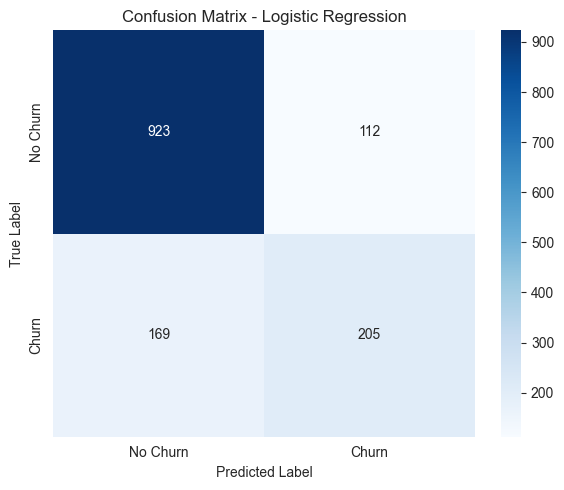

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [12]:
# Feature importance via model coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("Top 10 features influencing churn (by absolute coefficient):\n")
print(coef_df.head(10))

Top 10 features influencing churn (by absolute coefficient):

             Feature  Coefficient
4             tenure    -1.214494
5       PhoneService    -0.938378
17    MonthlyCharges     0.730792
14          Contract    -0.722741
18      TotalCharges     0.478594
15  PaperlessBilling     0.394711
8     OnlineSecurity    -0.286442
11       TechSupport    -0.264776
3         Dependents    -0.238614
7    InternetService     0.232745


**Observations based on model performance:**

1. The model achieves reasonable overall accuracy, but on the Telco dataset churn is imbalanced (~27% churn), so **recall on the churn class is typically lower than precision** — the model misses some customers who actually churn.
2. Contract type, tenure, and monthly charges tend to have the largest coefficients, indicating that **month-to-month contracts, short tenure, and higher monthly charges are strongly associated with churn**.
3. The confusion matrix generally shows more false negatives than false positives, meaning the model is more conservative about predicting churn — a business trade-off worth adjusting the classification threshold for, depending on whether the cost of missing a churner outweighs the cost of a false alarm.

*(Exact numbers will populate once you run this notebook with the actual Kaggle CSV — replace the observations above with your own numeric results.)*


## Task 5: Conclusion (1 Mark)

Logistic Regression proved to be an effective and interpretable baseline model for predicting customer churn on the Telco dataset.

 The analysis shows that contract type, tenure, monthly charges, and the presence of add-on services (such as online security and tech support) are among the strongest predictors of churn — customers on month-to-month contracts with short tenure and higher monthly bills are considerably more likely to leave.
 
  Customers with longer tenure and long-term contracts (one or two years) show much lower churn rates, suggesting that loyalty incentives and bundled services help retention.
  
   One key limitation of Logistic Regression here is that it assumes a **linear relationship between the features and the log-odds of churn**, so it can struggle to capture complex, non-linear interactions between variables (e.g., how tenure and contract type jointly affect churn) that tree-based or ensemble models (Random Forest, XGBoost) might capture more accurately.
